In [1]:
import os

# Clone ECP repository if not already cloned
if not os.path.exists("ECP"):
    os.system("git clone https://github.com/fouratifares/ECP.git")

In [2]:
cd ECP

/content/ECP


In [3]:
from optimizers.ECP import ECP
import numpy as np
import matplotlib.pyplot as plt

# ECP on Implemented Functions


In [4]:
# List the available functions
ls ./functions

SyntaxError: invalid syntax (2728062669.py, line 2)

The Global Search is Completed
Best Point: [ 0.05812144 -0.72617123]
Maximum Value: 1.025731113152134




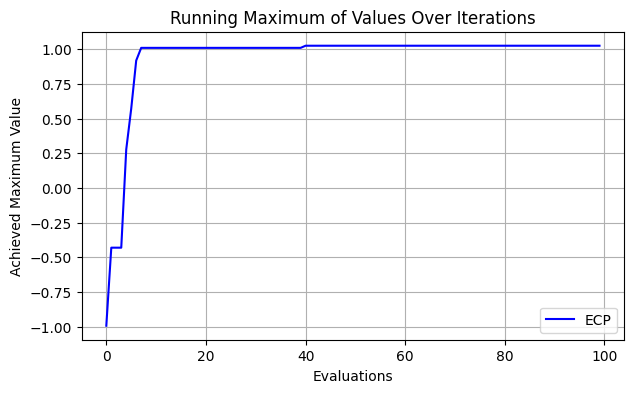

In [ ]:
# Import Camel function from /functions
from functions.camel import Function

f = Function()
points, values, epsilons = ECP(f, n = 100)

# Retrieve the corresponding point
best_point = points[np.argmax(values)]

print("The Global Search is Completed")
print("Best Point:", best_point)
print("Maximum Value:", max(values))
print("\n")

# Compute running maximum
running_max = np.maximum.accumulate(values)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(running_max, label="ECP", color="blue")
plt.xlabel("Evaluations")
plt.ylabel("Achieved Maximum Value")
plt.title("Running Maximum of Values Over Iterations")
plt.legend()
plt.grid()
plt.show()

# Multi-Objective Lipschitz Optimization Experiments
### Numerical Evaluation for Aligned Multi-Objective ECP

This notebook implements and evaluates a **multi-objective extension of Lipschitz global optimization algorithms**, inspired by:

- **Aligned Multi-Objective Optimization (AMOO)**
- **Every Call is Precious (ECP)** global optimization

The goal is to understand whether **alignment between objectives can accelerate black-box global optimization**.

---

## 1. Background

### Multi-Objective Optimization

In multi-objective optimization we optimize

$$
F(x) = (f_1(x), \dots, f_m(x))
$$

instead of a single function.

Traditional work focuses on **Pareto frontiers**, where objectives conflict.

However, in many machine learning systems objectives are **not conflicting**, but rather **aligned**:

- multi-task learning
- proxy objectives
- auxiliary RL rewards
- multiple evaluation metrics

This motivates the **Aligned Multi-Objective Optimization (AMOO)** framework.

---

## 2. Alignment Assumption

AMOO assumes that all objectives share a common optimum:

$$
x^\star \in \arg\min f_i(x) \quad \forall i
$$

This means multiple objectives describe the **same underlying solution** but with different curvature or informativeness.

---

## 3. What AMOO Actually Tested

AMOO **did not** test black-box optimization benchmarks.

Instead, they constructed synthetic objective families where:

- all objectives share the **same optimal point**
- curvature varies between objectives

Their experiments focused on two key synthetic scenarios.

### 3.1 Selection Example

Their toy objectives were defined through a shared target network output and losses of the form

$$
f_i(\theta) =
\frac{1}{|D|}
\sum_{x \in D}
\left(
(h_\theta(x) - h_{\theta^\star}(x))^\top
H_i
(h_\theta(x) - h_{\theta^\star}(x))
\right)^{\alpha_i}.
$$

Key idea:

- some objectives are more informative than others
- some objectives are relatively flatter or weaker
- the algorithm should learn to emphasize the most useful objective

Parameters varied in the experiments:

- exponent $\alpha_i$
- positive definite matrix $H_i$

Purpose:

to test whether AMOO algorithms can **adaptively focus on the most informative objective**.

### 3.2 Curvature Example

AMOO also studied a setting where curvature varies across objectives while keeping the same optimum.

Some objectives were:

- highly curved and informative in certain regions
- flatter and less informative in other regions

Goal:

to test whether AMOO algorithms can exploit curvature differences to accelerate convergence.

---

## 4. Key Limitation of AMOO Experiments

AMOO experiments **did not evaluate black-box global optimization problems**.

Instead they focused on **structured differentiable objectives with gradient access**.

This leaves an open question:

> Can alignment also accelerate **black-box global optimization**?

---

## 5. Our Setting

We study **Aligned Multi-Objective Lipschitz Optimization**.

Assume

$$
f_1, \dots, f_m \in \mathrm{Lip}(L_i)
$$

and

$$
x^\star \in \arg\min f_i(x)
\quad \text{for all objectives } i.
$$

Each objective may have a different Lipschitz constant.

---

## 6. Algorithmic Idea

The classical **ECP algorithm** maintains a Lipschitz envelope to determine whether a candidate point is worth evaluating.

We extend this idea to multiple aligned objectives.

### Multi-Objective Acceptance Region

For each objective $i$, define

$$
A_{i,t}
=
\left\{
x :
\max_j \bigl(f_i(x_j) - \epsilon_{i,t}\|x-x_j\|\bigr)
\le
\min_j f_i(x_j)
\right\}.
$$

The **multi-objective acceptance region** is the intersection

$$
A_t = \bigcap_i A_{i,t}.
$$

A point is evaluated only if it is **promising for every objective**.

---

## 7. Experimental Design

We perform black-box experiments similar in spirit to AMOO, but adapted to global optimization.

### Base benchmark functions

We use standard global optimization benchmarks:

- Camel
- Hartmann
- Rastrigin
- Himmelblau
- Rosenbrock

These come from the ECP benchmark suite.

---

## 8. Generating Aligned Objectives

To create aligned objectives we transform a base function $g(x)$.

### Exact alignment

$$
f_i(x) = \phi_i(g(x))
$$

where $\phi_i$ is monotone.

This preserves the same optimizer.

### Approximate alignment

$$
f_i(x) = g(x) + \delta_i h_i(x)
$$

where $h_i(x)$ is a small perturbation term.

This simulates **realistic imperfect alignment**.

---

## 9. Baselines

We compare against several standard approaches:

1. **Single-objective ECP**
2. **Equal-weight scalarization**

$$
f(x) = \frac{1}{m}\sum_i f_i(x)
$$

3. **Lexicographic optimization**
4. **Random search**

---

## 10. Metrics

We evaluate performance using **worst-objective regret**:

$$
R(n)
=
\max_i
\left(
\min_x f_i(x)
-
\min_{j \le n} f_i(x_j)
\right).
$$

This measures how well the algorithm solves **all objectives simultaneously**.

---

## 11. Goal of These Experiments

The experiments test the hypothesis:

> If objectives are aligned, exploiting multiple objectives should reduce the search space faster than optimizing any single objective.

This notebook implements the algorithms and runs the benchmark experiments.

---


In [ ]:
import numpy as np


def Uniform(X: np.array):
    """
    Generates a random point within the feasible region X.

    X: The feasible region (numpy array).
    """

    theta = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        theta[i] = np.random.uniform(X[i, 0], X[i, 1])
    return theta


def growth_condition(last_nb_samples, max_slope):
    """
    Checks whether the slope of the last points of the nb_samples vs. nb_evaluations curve exceeds max_slope.
    """
    slope = (last_nb_samples[-1] - last_nb_samples[0]) / (len(last_nb_samples) - 1)
    return slope > max_slope


def acceptance_condition(x, values, epsilon, points, strict=False):
    """
    Verifies the acceptance condition based on the current values and explored points.

    values: Array of function values from previously explored points (numpy array).
    x: The point to be evaluated (numpy array).
    epsilon: A small value used for the condition (float).
    points: The set of previously explored points (numpy array).
    strict: Whether the condition should be strictly greater (bool).
    """
    max_val = np.max(values)
    left_min = np.min(values + epsilon * np.linalg.norm(x - points, ord=2, axis=1))

    if strict:
        return left_min > max_val
    else:
        return left_min >= max_val

In [7]:
!sed -n '1,220p' /content/ECP/utils/runs.py


import argparse
import os
import numpy as np
import time
from optimizers.ECP import ECP
from optimizers.ECPv2 import ECPv2


def convert_to_function(name):
    """
    Converts a function name (string) into the actual function reference.

    Args:
    - name: The name of the function as a string.

    Returns:
    - A list containing the corresponding function reference.
    """

    functions = []

    if name in globals():
        functions.append(globals()[name])
    else:
        raise ValueError(f"'{name}' is not defined or imported.")

    return functions


def cli():
    """Parses command-line arguments."""
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--function", "-f", type=str, help="Function to maximize", required=True
    )
    parser.add_argument(
        "--n_eval", "-n", type=int, help="Number of evaluations (budget)", required=True
    )
    parser.add_argument("--n_run", "-r", type=int, help="Number of runs", required=True)
    parser.add_a

In [6]:
#gets the original ECP algorithm
!sed -n '1,220p' /content/ECP/utils/utils.py


import numpy as np


def Uniform(X: np.array):
    """
    Generates a random point within the feasible region X.

    X: The feasible region (numpy array).
    """

    theta = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        theta[i] = np.random.uniform(X[i, 0], X[i, 1])
    return theta


def growth_condition(last_nb_samples, max_slope):
    """
    Checks whether the slope of the last points of the nb_samples vs. nb_evaluations curve exceeds max_slope.
    """
    slope = (last_nb_samples[-1] - last_nb_samples[0]) / (len(last_nb_samples) - 1)
    return slope > max_slope


def acceptance_condition(x, values, epsilon, points, strict=False):
    """
    Verifies the acceptance condition based on the current values and explored points.

    values: Array of function values from previously explored points (numpy array).
    x: The point to be evaluated (numpy array).
    epsilon: A small value used for the condition (float).
    points: The set of previously explored points

In [9]:
!sed -n '1,220p' /content/ECP/optimizers/ECP.py


from collections import deque
from utils.utils import *
import numpy as np


def ECP(f, n: int, epsilon=1e-2, tau_=1.001, C=1000):
    """
    f: The class of the function to be maximized (class)
    n: The number of function evaluations (int)
    epsilon: A small value (epsilon_1 > 0)
    tau_: A scaling factor (tau_ > 1)
    C: A constant (C > 1)
    """

    # Initialize variables
    t = 1
    tau = max(1 + (1 / (n * f.dimensions)), tau_)

    # Generate the first random point
    X_1 = Uniform(f.bounds)
    nb_samples = 1

    # Track the number of samples in the last step
    last_nb_samples = deque([1], maxlen=2)

    # Initialize the points and corresponding function values
    points = X_1.reshape(1, -1)
    values = np.array([f(X_1)])

    # Store the current epsilon value
    epsilons = [epsilon]

    # Main optimization loop
    while t < n:
        count_inner_growth = 0
        while True:
            # Generate the next random point
            X_tp1 = Uniform(f.bounds)


In [ ]:
acceptance_condition_mo

In [ ]:
from collections import deque
from utils.utils import *
import numpy as np


def ECP(f, n: int, epsilon=1e-2, tau_=1.001, C=1000):
    """
    f: The class of the function to be maximized (class)
    n: The number of function evaluations (int)
    epsilon: A small value (epsilon_1 > 0)
    tau_: A scaling factor (tau_ > 1)
    C: A constant (C > 1)
    """

    # Initialize variables
    t = 1
    tau = max(1 + (1 / (n * f.dimensions)), tau_)

    # Generate the first random point
    X_1 = Uniform(f.bounds)
    nb_samples = 1

    # Track the number of samples in the last step
    last_nb_samples = deque([1], maxlen=2)

    # Initialize the points and corresponding function values
    points = X_1.reshape(1, -1)
    values = np.array([f(X_1)])

    # Store the current epsilon value
    epsilons = [epsilon]

    # Main optimization loop
    while t < n:
        count_inner_growth = 0
        while True:
            # Generate the next random point
            X_tp1 = Uniform(f.bounds)
            nb_samples += 1
            last_nb_samples[-1] = nb_samples

            # Check if the point satisfies the acceptance condition
            if acceptance_condition(X_tp1, values, epsilon, points, strict=False):
                points = np.concatenate((points, X_tp1.reshape(1, -1)))
                break

            # Check if the growth condition is met
            elif growth_condition(last_nb_samples, C):
                count_inner_growth += 1
                epsilon *= tau
                last_nb_samples[-1] = 0

        # Evaluate the function at the new point
        value = f(X_tp1)
        t += 1
        epsilon *= tau
        epsilons.append(epsilon)

        # Add the new point and its value to the results
        values = np.concatenate((values, np.array([value])))

        # Reset the sample count for the next iteration
        last_nb_samples.append(0)

    return points, values, np.array(epsilons)


# Multiobjective ALigned Extension

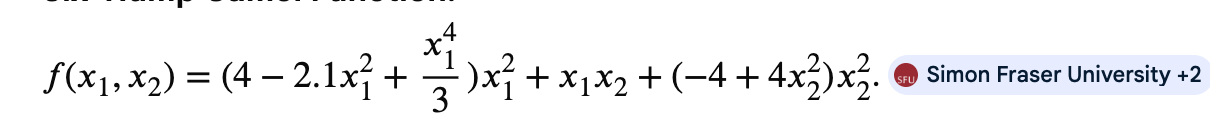

Testing 2 functions

In [5]:
import numpy as np

class AlignedCamel2Obj:
    def __init__(self):
        self.bounds = np.array([[-2.0, 2.0], [-1.5, 1.5]])

    def base(self, x):
      x1, x2 = x
      return (
        (4 - 2.1*x1**2 + (x1**4)/3) * x1**2
        + x1*x2
        + (-4 + 4*x2**2) * x2**2
    )

    def evaluate(self, x):
        g = -self.base(x)   # convert to maximization if needed
        f1 = g
        f2 = np.tanh(g)
        return np.array([f1, f2])

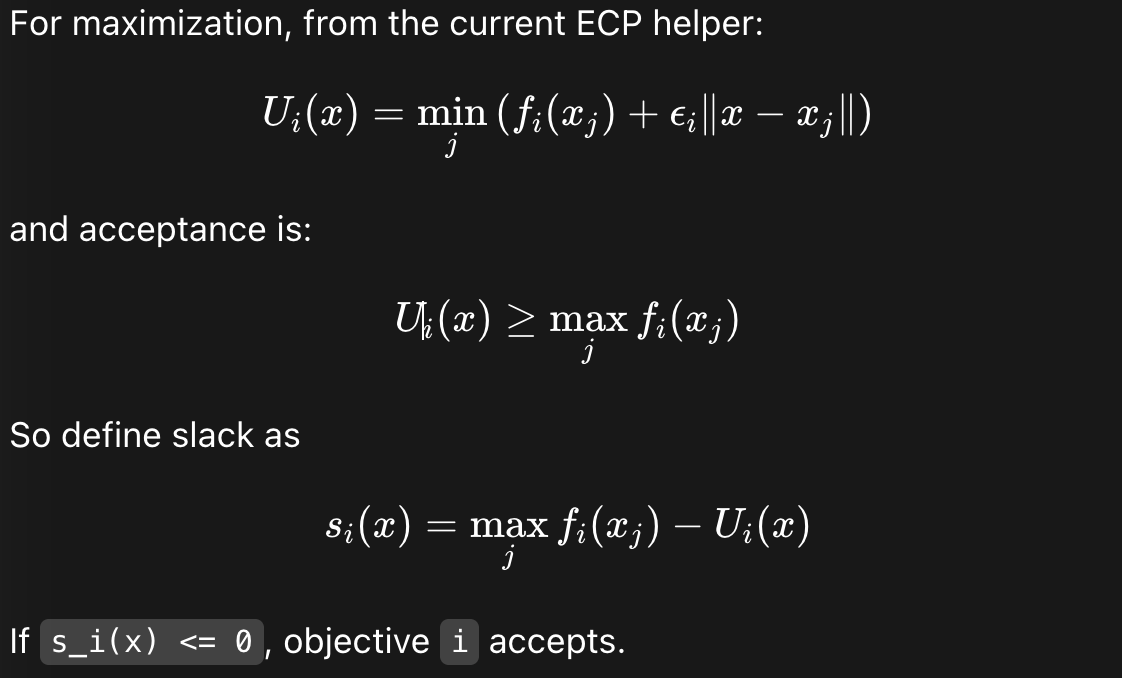

Remark: our objective violation is defined in the maximization regime, and this is translated to match ECP's maximization $s_i^{max}(x)$

 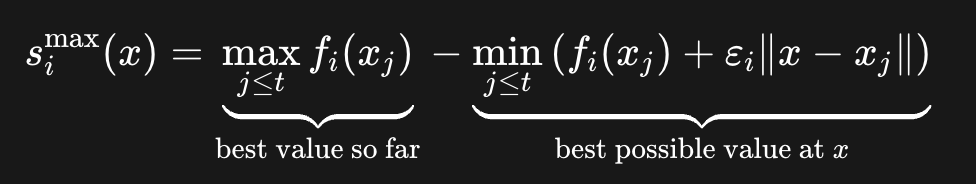

In [7]:
def objective_slacks(x, points, values_list, epsilons):
    slacks = []
    for i in range(len(values_list)):
        values = np.array(values_list[i])
        eps = epsilons[i]
        upper_env = np.min(values + eps * np.linalg.norm(x - points, axis=1))
        slack = np.max(values) - upper_env
        slacks.append(slack)
    return np.array(slacks)


def most_blocking_objective(x, points, values_list, epsilons):
    slacks = objective_slacks(x, points, values_list, epsilons)
    return int(np.argmax(slacks)), slacks

def acceptance_condition_mo(x, points, values_list, epsilons):
    """
    Multi-objective ECP acceptance test.

    For each objective i, form the optimistic upper envelope
        U_i(x) = min_j [ f_i(x_j) + eps_i * ||x - x_j|| ].

    Define slack
        s_i(x) = max_j f_i(x_j) - U_i(x).

    Interpretation:
      - s_i(x) <= 0 means x is still admissible for objective i
      - accept only if admissible for all objectives
    """
    x = np.asarray(x, dtype=float)
    points = np.asarray(points, dtype=float)

    slacks = []
    for i in range(len(values_list)):
        values = np.asarray(values_list[i], dtype=float)
        eps = float(epsilons[i])

        upper_env = np.min(values + eps * np.linalg.norm(x - points, axis=1))
        slack = np.max(values) - upper_env
        slacks.append(slack)

    slacks = np.array(slacks, dtype=float)
    accepted = np.all(slacks <= 0)
    return accepted, slacks

In [6]:
def MO_ECP(f, n=50, epsilon_init=1e-2, tau=1.05, max_rejects=100, rng=None):
    """
    Multi-objective ECP sampler.

    Inputs:
      f.evaluate(x) -> np.array of shape (m,)
      f.bounds      -> array-like of shape (d,2)

    Returns:
      points        : (n,d) sampled accepted points
      values_list   : list of m arrays, one per objective
      epsilons      : final per-objective Lipschitz estimates
    """
    if rng is None:
        rng = np.random.default_rng()

    bounds = np.asarray(f.bounds, dtype=float)
    lows = bounds[:, 0]
    highs = bounds[:, 1]

    def Uniform():
        return rng.uniform(lows, highs)

    x1 = Uniform()
    y1 = np.asarray(f.evaluate(x1), dtype=float)
    m = len(y1)

    points = [x1]
    values_list = [[y1[i]] for i in range(m)]
    epsilons = np.full(m, epsilon_init, dtype=float)
    reject_counts = np.zeros(m, dtype=int)

    while len(points) < n:
        x = Uniform()

        accepted, slacks = acceptance_condition_mo(
            x=x,
            points=np.array(points),
            values_list=values_list,
            epsilons=epsilons,
        )

        if accepted:
            y = np.asarray(f.evaluate(x), dtype=float)
            points.append(x)
            for i in range(m):
                values_list[i].append(y[i])
            reject_counts[:] = 0
        else:
            i_star = int(np.argmax(slacks))
            reject_counts[i_star] += 1

            if reject_counts[i_star] >= max_rejects:
                epsilons[i_star] *= tau
                reject_counts[i_star] = 0

    return np.array(points), [np.array(v, dtype=float) for v in values_list], epsilons

In [8]:
def evaluate_worst_regret(points, f, x_star=None, grid=None):
    """
    Compute worst-objective simple regret curve for maximization.

    Regret at time t:
        R_t = max_i [ f_i(x_star) - max_{s <= t} f_i(x_s) ].

    You should pass x_star if known.
    If x_star is None, this function can approximate the optimum using a grid
    in 2D only.

    Returns:
      worst_regret : array of length len(points)
      best_so_far_per_obj : (T,m) array
      opt_vals : (m,) array
    """
    points = np.asarray(points, dtype=float)
    T = len(points)

    sampled_vals = np.array([f.evaluate(x) for x in points], dtype=float)  # (T,m)
    best_so_far_per_obj = np.maximum.accumulate(sampled_vals, axis=0)

    if x_star is not None:
        opt_vals = np.asarray(f.evaluate(np.asarray(x_star, dtype=float)), dtype=float)
    else:
        # crude fallback: only for 2D if you want a quick approximation
        bounds = np.asarray(f.bounds, dtype=float)
        d = bounds.shape[0]
        if d != 2:
            raise ValueError("Pass x_star explicitly unless f is 2D and grid search is acceptable.")
        if grid is None:
            grid = 200

        xs = np.linspace(bounds[0, 0], bounds[0, 1], grid)
        ys = np.linspace(bounds[1, 0], bounds[1, 1], grid)

        vals = []
        for x in xs:
            for y in ys:
                vals.append(f.evaluate(np.array([x, y], dtype=float)))
        vals = np.array(vals, dtype=float)
        opt_vals = np.max(vals, axis=0)

    worst_regret = np.max(opt_vals[None, :] - best_so_far_per_obj, axis=1)
    return worst_regret, best_so_far_per_obj, opt_vals

# Testing interface for aligned Camel


In [10]:
import numpy as np

def make_aligned_objectives(base_f, x_star, params):
    """
    Wrap a scalar base benchmark into an aligned multi-objective family.

    Each objective has form
        f_i(x) = a_i * h(x) + b_i - c_i * || B_i (x - x_star) ||_2

    where:
      - h = base_f.evaluate_scalar
      - a_i > 0 preserves the maximizer
      - b_i is just a shift
      - c_i >= 0 controls extra penalty away from x_star
      - B_i changes anisotropy

    Expected interface:
      base_f.bounds : array-like of shape (d,2)
      base_f.evaluate_scalar(x) -> float

    params: list of dicts, each with keys
      - "a" : positive float
      - "b" : float
      - "c" : nonnegative float
      - "B" : array-like (d,d), usually diagonal
    """

    class AlignedMultiObjectiveFunction:
        def __init__(self, base_f, x_star, params):
            self.base_f = base_f
            self.x_star = np.asarray(x_star, dtype=float)
            self.params = params
            self.bounds = np.asarray(base_f.bounds, dtype=float)

        def evaluate(self, x):
            x = np.asarray(x, dtype=float)
            h = float(self.base_f.evaluate_scalar(x))

            vals = []
            for p in self.params:
                a = float(p["a"])
                b = float(p["b"])
                c = float(p["c"])
                B = np.asarray(p["B"], dtype=float)

                penalty = c * np.linalg.norm(B @ (x - self.x_star), ord=2)
                vals.append(a * h + b - penalty)

            return np.array(vals, dtype=float)

    return AlignedMultiObjectiveFunction(base_f, x_star, params)

In [23]:
#defining a scalar base benchmark

class CamelLike:
    def __init__(self):
        self.bounds = np.array([[-2, 2], [-1, 1]], dtype=float)
        self.x_star = np.array([0.0898, -0.7126], dtype=float)

    def evaluate_scalar(self, x):
        x1, x2 = x
        camel_neg = -((4 - 2.1*x1**2 + (x1**4)/3) * x1**2
                      + x1*x2
                      + (-4 + 4*x2**2) * x2**2)
        # small tie-breaking penalty so there is one preferred maximizer
        return camel_neg - 0.05 * np.linalg.norm(np.array(x) - self.x_star)


base_f = CamelLike()
x_star = base_f.x_star  # replace with true optimizer if different

params = [
    {"a": 1.0,  "b": 0.0,  "c": 0.15, "B": np.diag([1.0, 1.0])},
    {"a": 1.05, "b": 0.1,  "c": 0.20, "B": np.diag([2.0, 0.5])},
    {"a": 0.95, "b": -0.1, "c": 0.18, "B": np.diag([0.5, 2.0])},
]

f = make_aligned_objectives(base_f, x_star, params)

points, values_list, epsilons = MO_ECP(f, n=200, epsilon_init=1e-2, tau=1.1, max_rejects=20)
worst_regret, best_so_far_per_obj, opt_vals = evaluate_worst_regret(points, f, x_star=x_star)

print("final epsilons:", epsilons)
print("minima/maxima for each function:", opt_vals)
print("final worst-objective regret:", worst_regret[-1])

final epsilons: [10.511532   12.71895371 10.511532  ]
opt vals: [1.03162842 1.18320984 0.880047  ]
final worst-objective regret: 0.008553866141692734


## Aligned multi-objective Camel benchmark

We construct a synthetic aligned multi-objective benchmark from a tie-broken negated six-hump camel function. Let
$$
h(x)
=
-\Bigg[
\left(4-2.1x_1^2+\frac{x_1^4}{3}\right)x_1^2
+
x_1x_2
+
(-4+4x_2^2)x_2^2
\Bigg]
-
\lambda \|x-x^\star\|_2,
$$
where $x^\star=(0.0898,-0.7126)$ and $\lambda=0.05.$ (see https://www.sfu.ca/~ssurjano/camel6.html for further information on the six-hump-camel function) NOTE: The small penalty term $\lambda$ breaks the symmetry of the original negated six-hump camel function and induces a unique preferred maximizer at $x^\star$.

From this scalar benchmark, we define \(m=3\) aligned objectives
$$
f_i(x)=a_i h(x)+b_i-c_i\|B_i(x-x^\star)\|_2, \qquad i=1,2,3,
$$
with $$a_i>0$$, $$c_i\ge 0 $$, and diagonal matrices $$B_i$$. This preserves a shared optimizer at $x^\star$ while generating distinct objective geometries.

We evaluate performance using worst-objective simple regret:
$$
R_t
=
\max_{i\in\{1,2,3\}}
\left(
f_i(x^\star)-\max_{s\le t} f_i(x_s)
\right),
$$
where $x_1,\dots,x_t$ are the accepted samples of the multi-objective ECP procedure.

In the current run, the reference optimum values are
$$
f(x^\star)=(1.0316,\;1.1832,\;0.8800),
$$
and the final worst-objective regret is
$$
R_{200}\approx 8.55\times 10^{-3}.
$$
This indicates that after $200$ accepted samples, the algorithm identifies points whose objective values are uniformly close to the shared optimum across all three aligned objectives.

The current experiment therefore serves as a first sanity check that:
1. the benchmark construction produces distinct but aligned Lipschitz objectives,
2. the multi-objective acceptance rule is executable end-to-end, and
3. the accepted sample set approaches the common optimum simultaneously across all objectives.

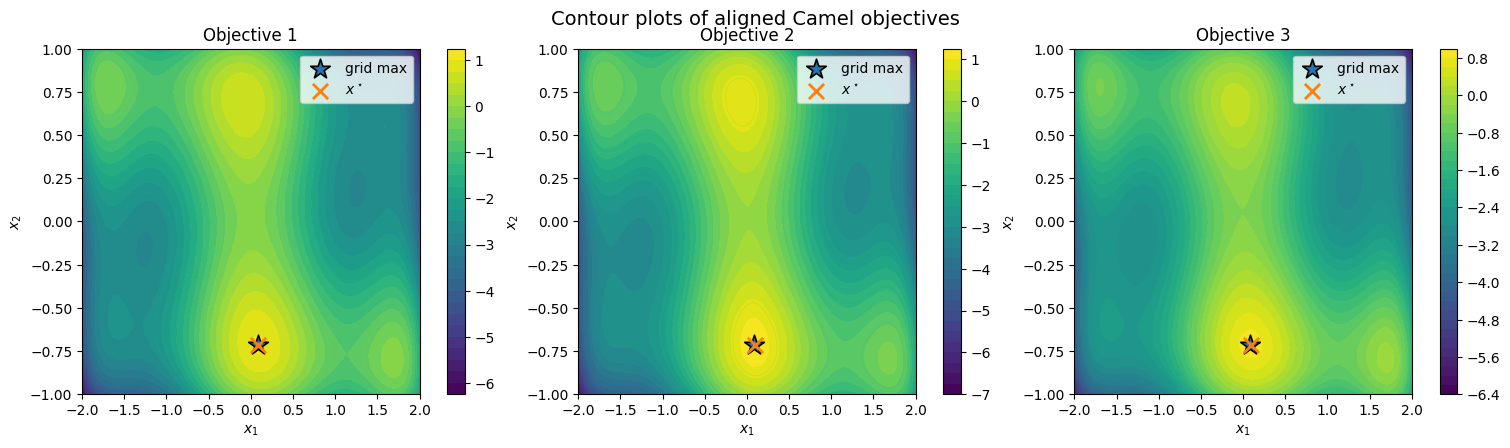

Estimated maximizers from grid search:
obj 1: x_max = [ 0.08695652 -0.71237458], f_max ≈ 1.031026
obj 2: x_max = [ 0.08695652 -0.71237458], f_max ≈ 1.181889
obj 3: x_max = [ 0.08695652 -0.71237458], f_max ≈ 0.879612


In [24]:
import numpy as np
import matplotlib.pyplot as plt

def contour_figure_aligned_family(f, x_star=None, grid=300):
    bounds = np.asarray(f.bounds, dtype=float)
    assert bounds.shape[0] == 2, "Only implemented for 2D."

    xs = np.linspace(bounds[0, 0], bounds[0, 1], grid)
    ys = np.linspace(bounds[1, 0], bounds[1, 1], grid)
    X, Y = np.meshgrid(xs, ys)

    m = len(f.evaluate(np.array([xs[0], ys[0]], dtype=float)))
    Zs = np.zeros((m, grid, grid), dtype=float)

    for i in range(grid):
        for j in range(grid):
            Zs[:, i, j] = f.evaluate(np.array([X[i, j], Y[i, j]], dtype=float))

    max_points = []
    max_vals = []
    for k in range(m):
        idx = np.unravel_index(np.argmax(Zs[k]), Zs[k].shape)
        max_points.append(np.array([X[idx], Y[idx]]))
        max_vals.append(Zs[k][idx])

    fig, axes = plt.subplots(1, m, figsize=(5*m, 4.2), constrained_layout=True)
    if m == 1:
        axes = [axes]

    for k, ax in enumerate(axes):
        cf = ax.contourf(X, Y, Zs[k], levels=35)
        ax.contour(X, Y, Zs[k], levels=12, linewidths=0.5)
        plt.colorbar(cf, ax=ax)

        mp = max_points[k]
        ax.scatter(mp[0], mp[1], marker="*", s=220, edgecolors="black", linewidths=1.2, label="grid max")
        if x_star is not None:
            ax.scatter(x_star[0], x_star[1], marker="x", s=120, linewidths=2, label=r"$x^\star$")

        ax.set_title(f"Objective {k+1}")
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
        ax.legend(loc="best")

    plt.suptitle("Contour plots of aligned Camel objectives", y=1.03, fontsize=14)
    plt.show()

    print("Estimated maximizers from grid search:")
    for k in range(m):
        print(f"obj {k+1}: x_max = {max_points[k]}, f_max ≈ {max_vals[k]:.6f}")

    return {
        "X": X,
        "Y": Y,
        "Zs": Zs,
        "max_points": np.array(max_points),
        "max_vals": np.array(max_vals),
    }

contour_results = contour_figure_aligned_family(f, x_star=x_star, grid=300)

This is to confirm that the algorithm correctly arrives at the true lipschitz constant (with sufficient budget n)

In [25]:
import pandas as pd

def lipschitz_table(f, grid=250):
    bounds = np.asarray(f.bounds, dtype=float)
    assert bounds.shape[0] == 2, "Only implemented for 2D."

    xs = np.linspace(bounds[0, 0], bounds[0, 1], grid)
    ys = np.linspace(bounds[1, 0], bounds[1, 1], grid)
    X, Y = np.meshgrid(xs, ys)

    dx = xs[1] - xs[0]
    dy = ys[1] - ys[0]

    # base function grid
    H = np.zeros((grid, grid), dtype=float)
    for i in range(grid):
        for j in range(grid):
            H[i, j] = f.base_f.evaluate_scalar(np.array([X[i, j], Y[i, j]], dtype=float))

    dHdy, dHdx = np.gradient(H, dy, dx)
    base_grad_norm = np.sqrt(dHdx**2 + dHdy**2)
    L_base_est = np.max(base_grad_norm)

    rows = []
    m = len(f.params)

    for k in range(m):
        Z = np.zeros((grid, grid), dtype=float)
        for i in range(grid):
            for j in range(grid):
                Z[i, j] = f.evaluate(np.array([X[i, j], Y[i, j]], dtype=float))[k]

        dZdy, dZdx = np.gradient(Z, dy, dx)
        grad_norm = np.sqrt(dZdx**2 + dZdy**2)
        L_est = np.max(grad_norm)

        p = f.params[k]
        a = float(p["a"])
        b = float(p["b"])
        c = float(p["c"])
        B = np.asarray(p["B"], dtype=float)
        B_op = np.linalg.norm(B, 2)
        L_upper = a * L_base_est + c * B_op

        rows.append({
            "objective": k + 1,
            "a_i": a,
            "b_i": b,
            "c_i": c,
            "||B_i||_op": B_op,
            "Lip(base) est.": L_base_est,
            "Lip(obj) est.": L_est,
            "Lip(obj) upper bound": L_upper,
        })

    df = pd.DataFrame(rows)
    return df

lip_df = lipschitz_table(f, grid=250)
lip_df

,objective,a_i,b_i,c_i,||B_i||_op,Lip(base) est.,Lip(obj) est.,Lip(obj) upper bound
0,1,1.00,0.0,0.15,1.0,16.569854,16.718971,16.719854
1,2,1.05,0.1,0.20,2.0,16.569854,17.726041,17.798346
2,3,0.95,-0.1,0.18,2.0,16.569854,15.969483,16.101361


## Scalarization baseline

As a baseline, we also optimize the equal-weight scalarization
$$
g(x)=\frac{1}{m}\sum_{i=1}^m f_i(x),
$$
using the scalar ECP procedure. This baseline ignores the intersection-based multi-objective admissibility rule and instead reduces the problem to single-objective optimization.

We then evaluate the accepted sample set using the same worst-objective regret metric
$$
R_t
=
\max_i \left(f_i(x^\star)-\max_{s\le t}f_i(x_s)\right),
$$
so that both methods are compared on the same aligned multi-objective target.

In [26]:
def objective_slack_scalar(x, points, values, epsilon):
    values = np.asarray(values, dtype=float)
    points = np.asarray(points, dtype=float)
    upper_env = np.min(values + epsilon * np.linalg.norm(x - points, axis=1))
    slack = np.max(values) - upper_env
    return slack

def acceptance_condition_scalar(x, points, values, epsilon):
    slack = objective_slack_scalar(x, points, values, epsilon)
    return slack <= 0, slack

def ECP_scalar(g, bounds, n=50, epsilon_init=1e-2, tau=1.05, max_rejects=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    bounds = np.asarray(bounds, dtype=float)
    lows = bounds[:, 0]
    highs = bounds[:, 1]

    def Uniform():
        return rng.uniform(lows, highs)

    x1 = Uniform()
    y1 = float(g(x1))

    points = [x1]
    values = [y1]
    epsilon = float(epsilon_init)
    reject_count = 0

    while len(points) < n:
        x = Uniform()
        accepted, slack = acceptance_condition_scalar(
            x=x,
            points=np.array(points),
            values=np.array(values),
            epsilon=epsilon
        )

        if accepted:
            y = float(g(x))
            points.append(x)
            values.append(y)
            reject_count = 0
        else:
            reject_count += 1
            if reject_count >= max_rejects:
                epsilon *= tau
                reject_count = 0

    return np.array(points), np.array(values), epsilon

def make_scalarized_function(f, weights=None):
    m = len(f.evaluate(np.mean(f.bounds, axis=1)))
    if weights is None:
        weights = np.ones(m) / m
    weights = np.asarray(weights, dtype=float)
    weights = weights / np.sum(weights)

    def g(x):
        return float(np.dot(weights, f.evaluate(x)))
    return g, weights

g_scalar, weights = make_scalarized_function(f)

scalar_points, scalar_values, scalar_eps = ECP_scalar(
    g=g_scalar,
    bounds=f.bounds,
    n=200,
    epsilon_init=1e-2,
    tau=1.1,
    max_rejects=20
)

scalar_worst_regret, scalar_best_so_far_per_obj, scalar_opt_vals = evaluate_worst_regret(
    scalar_points,
    f,
    x_star=x_star
)

print("scalarization weights:", weights)
print("final scalar epsilon:", scalar_eps)
print("final scalarization worst-objective regret:", scalar_worst_regret[-1])

scalarization weights: [0.33333333 0.33333333 0.33333333]
final scalar epsilon: 13.990849085345795
final scalarization worst-objective regret: 0.009178965102941694


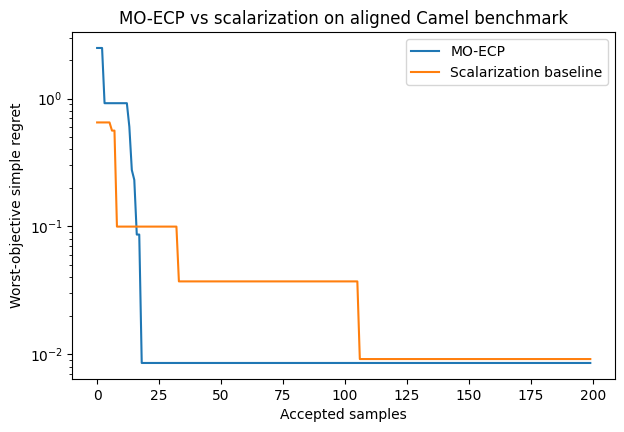

In [27]:
plt.figure(figsize=(7, 4.5))
plt.plot(worst_regret, label="MO-ECP")
plt.plot(scalar_worst_regret, label="Scalarization baseline")
plt.xlabel("Accepted samples")
plt.ylabel("Worst-objective simple regret")
plt.title("MO-ECP vs scalarization on aligned Camel benchmark")
plt.yscale("log")
plt.legend()
plt.show()

**MO_ECP reaches low worst-objective simple regret in fewer evaluated points**

## Moving forward

ECP paper presented a comparison of their algorithm wrt best function value found so far at a fixed amount of evaluations, and they provide secondary ablation studies (varying tau, C, and epsilon), e.g:

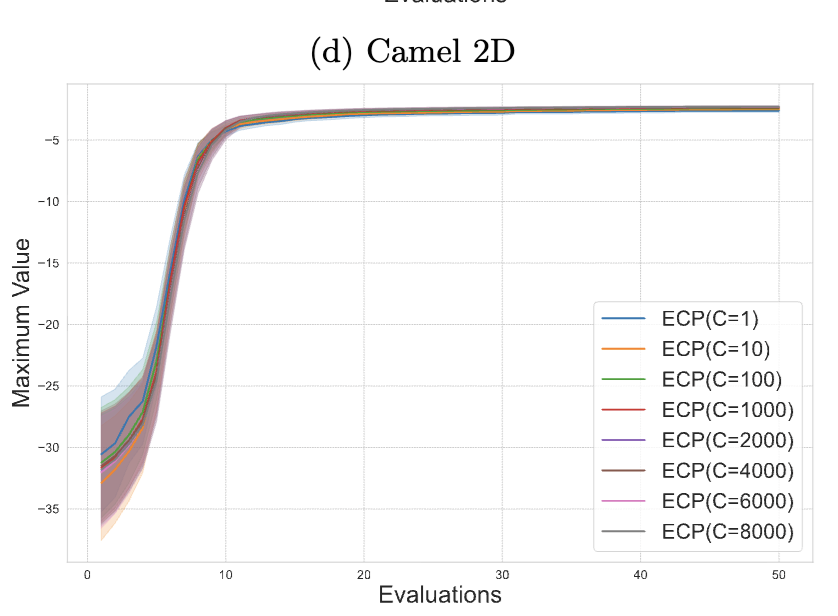

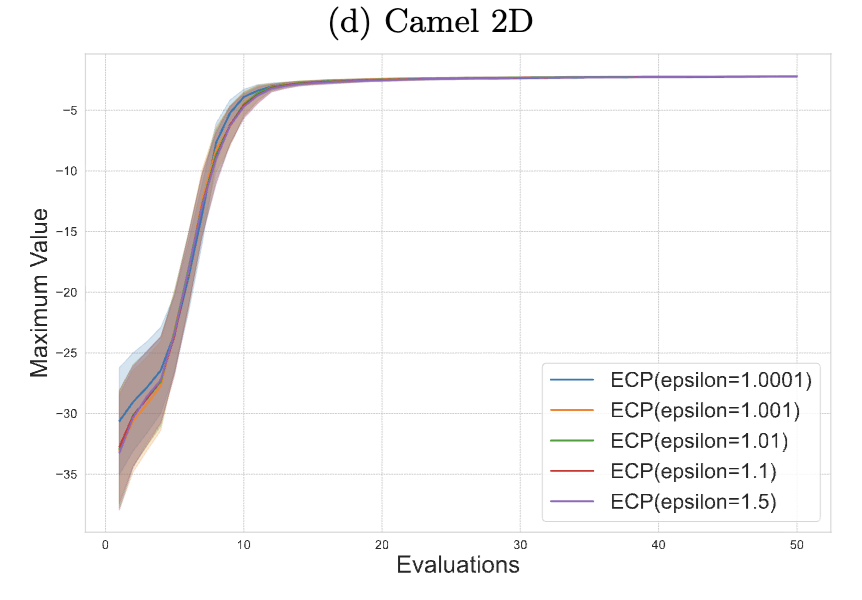

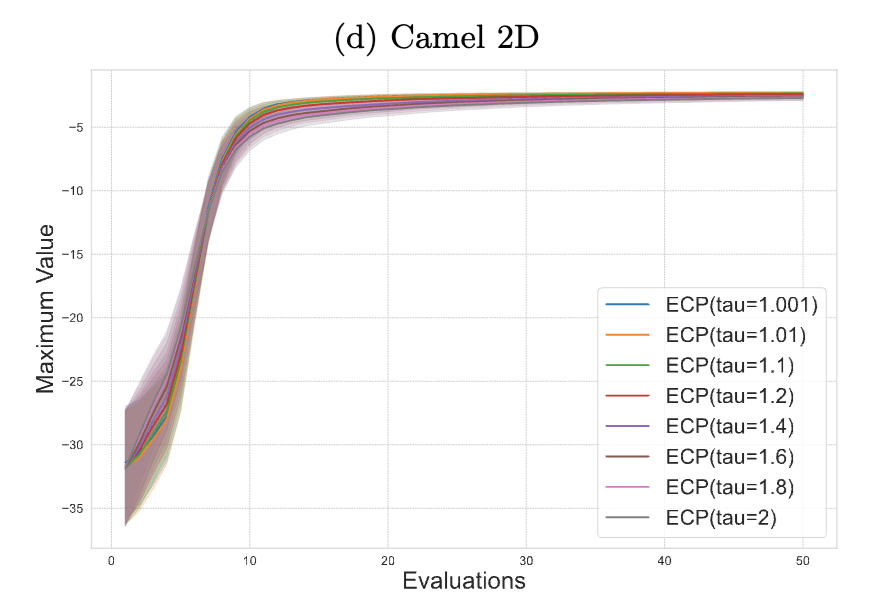

Given that we extend to alignment and multiobjective setting, we can additionally ablate:
- shared epsilon vs. per-objective epsilon
- m number of objectives
- alignment strength ($\epsilon$- alignment)

#lexicographic, random search, and alignment strength sweep

In [28]:
def approximate_common_reference_2d(f, grid=301):
    """
    Approximates the best common compromise point
        x_ref = argmax_x min_i f_i(x)
    on a dense 2D grid.

    This is the right reference once alignment is no longer exact.
    """
    bounds = np.asarray(f.bounds, dtype=float)
    assert bounds.shape[0] == 2, "Only implemented for 2D functions."

    xs = np.linspace(bounds[0, 0], bounds[0, 1], grid)
    ys = np.linspace(bounds[1, 0], bounds[1, 1], grid)

    best_x = None
    best_min_val = -np.inf
    best_vec = None

    for x1 in xs:
        for x2 in ys:
            x = np.array([x1, x2], dtype=float)
            vals = np.asarray(f.evaluate(x), dtype=float)
            score = np.min(vals)
            if score > best_min_val:
                best_min_val = score
                best_x = x.copy()
                best_vec = vals.copy()

    return best_x, best_vec, best_min_val


def evaluate_worst_regret_to_reference(points, f, x_ref):
    """
    Worst-objective simple regret relative to a reference point x_ref:
        R_t = max_i [ f_i(x_ref) - max_{s<=t} f_i(x_s) ]
    """
    points = np.asarray(points, dtype=float)
    sampled_vals = np.array([f.evaluate(x) for x in points], dtype=float)   # (T,m)
    best_so_far = np.maximum.accumulate(sampled_vals, axis=0)
    ref_vals = np.asarray(f.evaluate(np.asarray(x_ref, dtype=float)), dtype=float)
    worst_regret = np.max(ref_vals[None, :] - best_so_far, axis=1)
    return worst_regret, best_so_far, ref_vals


def objective_slack_scalar(x, points, values, epsilon):
    values = np.asarray(values, dtype=float)
    points = np.asarray(points, dtype=float)
    upper_env = np.min(values + epsilon * np.linalg.norm(x - points, axis=1))
    slack = np.max(values) - upper_env
    return slack


def acceptance_condition_scalar(x, points, values, epsilon):
    slack = objective_slack_scalar(x, points, values, epsilon)
    return slack <= 0, slack


def ECP_scalar(g, bounds, n=50, epsilon_init=1e-2, tau=1.05, max_rejects=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    bounds = np.asarray(bounds, dtype=float)
    lows = bounds[:, 0]
    highs = bounds[:, 1]

    def Uniform():
        return rng.uniform(lows, highs)

    x1 = Uniform()
    y1 = float(g(x1))

    points = [x1]
    values = [y1]
    epsilon = float(epsilon_init)
    reject_count = 0

    while len(points) < n:
        x = Uniform()
        accepted, slack = acceptance_condition_scalar(
            x=x,
            points=np.array(points),
            values=np.array(values),
            epsilon=epsilon
        )

        if accepted:
            y = float(g(x))
            points.append(x)
            values.append(y)
            reject_count = 0
        else:
            reject_count += 1
            if reject_count >= max_rejects:
                epsilon *= tau
                reject_count = 0

    return np.array(points), np.array(values), epsilon


def random_search(bounds, n=50, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    bounds = np.asarray(bounds, dtype=float)
    lows = bounds[:, 0]
    highs = bounds[:, 1]
    points = rng.uniform(lows, highs, size=(n, bounds.shape[0]))
    return points


def make_lexicographic_scalarized_function(f, scales=None, base=100.0):
    """
    Strong-priority lexicographic proxy:
      objective 1 dominates objective 2 dominates ...
    using weighted sum with exponentially decaying weights.

    Optional 'scales' rescales objectives before weighting.
    """
    m = len(f.evaluate(np.mean(f.bounds, axis=1)))

    if scales is None:
        scales = np.ones(m, dtype=float)
    scales = np.asarray(scales, dtype=float)

    weights = np.array([base ** (m - 1 - i) for i in range(m)], dtype=float)

    def g(x):
        vals = np.asarray(f.evaluate(x), dtype=float) / scales
        return float(np.dot(weights, vals))

    return g, weights, scales

In [29]:
def make_alignment_sweep_family(base_f, x_star, params, alignment_strength=1.0, shift_vectors=None, misalign_scale=0.0):
    """
    alignment_strength in [0,1]:
      1.0  -> exact alignment
      0.0  -> strongest misalignment in this family

    Base aligned term:
      a_i h(x) + b_i - c_i ||B_i (x-x_star)||

    Additional misalignment term:
      - misalign_scale * (1 - alignment_strength) * ||x - (x_star + shift_i)||

    This creates objective-specific local pulls away from x_star.
    """

    class SweepFamily:
        def __init__(self, base_f, x_star, params, alignment_strength, shift_vectors, misalign_scale):
            self.base_f = base_f
            self.x_star = np.asarray(x_star, dtype=float)
            self.params = params
            self.bounds = np.asarray(base_f.bounds, dtype=float)
            self.alignment_strength = float(alignment_strength)
            self.misalign_scale = float(misalign_scale)

            m = len(params)
            d = len(self.x_star)

            if shift_vectors is None:
                # fixed deterministic shifts for 3 objectives in 2D; extend if needed
                default = [
                    np.array([0.25, 0.00], dtype=float),
                    np.array([-0.18, 0.18], dtype=float),
                    np.array([0.00, -0.22], dtype=float),
                ]
                if m <= len(default) and d == 2:
                    self.shift_vectors = default[:m]
                else:
                    rng = np.random.default_rng(0)
                    self.shift_vectors = [rng.normal(size=d) for _ in range(m)]
                    self.shift_vectors = [v / (np.linalg.norm(v) + 1e-12) * 0.2 for v in self.shift_vectors]
            else:
                self.shift_vectors = [np.asarray(v, dtype=float) for v in shift_vectors]

        def evaluate(self, x):
            x = np.asarray(x, dtype=float)
            h = float(self.base_f.evaluate_scalar(x))

            vals = []
            mis_w = self.misalign_scale * (1.0 - self.alignment_strength)

            for p, shift in zip(self.params, self.shift_vectors):
                a = float(p["a"])
                b = float(p["b"])
                c = float(p["c"])
                B = np.asarray(p["B"], dtype=float)

                aligned_penalty = c * np.linalg.norm(B @ (x - self.x_star), ord=2)
                mis_center = self.x_star + shift
                misalign_penalty = mis_w * np.linalg.norm(x - mis_center, ord=2)

                vals.append(a * h + b - aligned_penalty - misalign_penalty)

            return np.array(vals, dtype=float)

    return SweepFamily(base_f, x_star, params, alignment_strength, shift_vectors, misalign_scale)

#MO-ECP with explicit seeding

In [30]:
def acceptance_condition_mo(x, points, values_list, epsilons):
    x = np.asarray(x, dtype=float)
    points = np.asarray(points, dtype=float)

    slacks = []
    for i in range(len(values_list)):
        values = np.asarray(values_list[i], dtype=float)
        eps = float(epsilons[i])
        upper_env = np.min(values + eps * np.linalg.norm(x - points, axis=1))
        slack = np.max(values) - upper_env
        slacks.append(slack)

    slacks = np.array(slacks, dtype=float)
    accepted = np.all(slacks <= 0)
    return accepted, slacks


def MO_ECP_seeded(f, n=50, epsilon_init=1e-2, tau=1.05, max_rejects=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    bounds = np.asarray(f.bounds, dtype=float)
    lows = bounds[:, 0]
    highs = bounds[:, 1]

    def Uniform():
        return rng.uniform(lows, highs)

    x1 = Uniform()
    y1 = np.asarray(f.evaluate(x1), dtype=float)
    m = len(y1)

    points = [x1]
    values_list = [[y1[i]] for i in range(m)]
    epsilons = np.full(m, epsilon_init, dtype=float)
    reject_counts = np.zeros(m, dtype=int)

    while len(points) < n:
        x = Uniform()

        accepted, slacks = acceptance_condition_mo(
            x=x,
            points=np.array(points),
            values_list=values_list,
            epsilons=epsilons,
        )

        if accepted:
            y = np.asarray(f.evaluate(x), dtype=float)
            points.append(x)
            for i in range(m):
                values_list[i].append(y[i])
            reject_counts[:] = 0
        else:
            i_star = int(np.argmax(slacks))
            reject_counts[i_star] += 1
            if reject_counts[i_star] >= max_rejects:
                epsilons[i_star] *= tau
                reject_counts[i_star] = 0

    return np.array(points), [np.array(v, dtype=float) for v in values_list], epsilons

#One run comparison among MO-ECP, Lexicographic, and random search

In [32]:
def compare_three_methods_once(
    f,
    n=200,
    epsilon_init=1e-2,
    tau=1.1,
    max_rejects=20,
    seed=0,
    ref_grid=301,
):
    rng_mo = np.random.default_rng(seed)
    rng_lex = np.random.default_rng(seed + 1)
    rng_rand = np.random.default_rng(seed + 2)

    # reference compromise point
    x_ref, ref_vals, ref_score = approximate_common_reference_2d(f, grid=ref_grid)

    # MO-ECP
    mo_points, mo_values_list, mo_eps = MO_ECP_seeded(
        f, n=n, epsilon_init=epsilon_init, tau=tau, max_rejects=max_rejects, rng=rng_mo
    )
    mo_regret, mo_best, _ = evaluate_worst_regret_to_reference(mo_points, f, x_ref)

    # Lexicographic
    lex_g, lex_weights, lex_scales = make_lexicographic_scalarized_function(f)
    lex_points, lex_values, lex_eps = ECP_scalar(
        g=lex_g, bounds=f.bounds, n=n, epsilon_init=epsilon_init, tau=tau, max_rejects=max_rejects, rng=rng_lex
    )
    lex_regret, lex_best, _ = evaluate_worst_regret_to_reference(lex_points, f, x_ref)

    # Random search
    rand_points = random_search(f.bounds, n=n, rng=rng_rand)
    rand_regret, rand_best, _ = evaluate_worst_regret_to_reference(rand_points, f, x_ref)

    results = {
        "x_ref": x_ref,
        "ref_vals": ref_vals,
        "ref_score_min": ref_score,
        "MO-ECP": {"points": mo_points, "regret": mo_regret, "final_regret": mo_regret[-1]},
        "Lexicographic": {"points": lex_points, "regret": lex_regret, "final_regret": lex_regret[-1]},
        "Random Search": {"points": rand_points, "regret": rand_regret, "final_regret": rand_regret[-1]},
    }
    return results


def plot_three_method_regret_curves(results, title_suffix=""):
    plt.figure(figsize=(7, 4.5))
    for method in ["MO-ECP", "Lexicographic", "Random Search"]:
        plt.plot(results[method]["regret"], label=f"{method} (final={results[method]['final_regret']:.4f})")
    plt.yscale("log")
    plt.xlabel("Accepted samples / evaluations")
    plt.ylabel("Worst-objective simple regret")
    plt.title(f"MO-ECP vs Lexicographic vs Random Search{title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("Reference compromise point:", results["x_ref"])
    print("Reference values at compromise point:", results["ref_vals"])
    print("Reference min-objective value:", results["ref_score_min"])
    print()
    for method in ["MO-ECP", "Lexicographic", "Random Search"]:
        print(f"{method}: final worst-objective regret = {results[method]['final_regret']:.6f}")

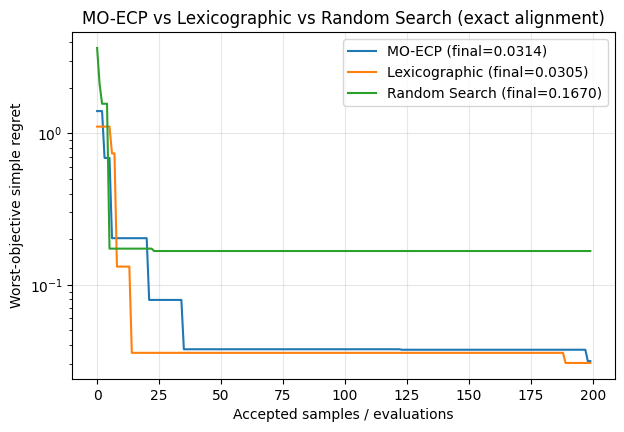

Reference compromise point: [ 0.09333333 -0.71333333]
Reference values at compromise point: [1.03085785 1.18155386 0.87941588]
Reference min-objective value: 0.8794158791217406

MO-ECP: final worst-objective regret = 0.031381
Lexicographic: final worst-objective regret = 0.030509
Random Search: final worst-objective regret = 0.167036


In [33]:
# exact alignment case
f_exact = make_alignment_sweep_family(
    base_f=base_f,
    x_star=x_star,
    params=params,
    alignment_strength=1.0,
    misalign_scale=0.25
)

one_run = compare_three_methods_once(
    f_exact,
    n=200,
    epsilon_init=1e-2,
    tau=1.1,
    max_rejects=20,
    seed=0,
    ref_grid=301,
)

plot_three_method_regret_curves(one_run, title_suffix=" (exact alignment)")

In [35]:
def alignment_sweep_experiment(
    base_f,
    x_star,
    params,
    alignment_levels,
    misalign_scale=0.25,
    n=200,
    seeds=10,
    epsilon_init=1e-2,
    tau=1.1,
    max_rejects=20,
    ref_grid=201,
):
    records = []

    for rho in alignment_levels:
        f_rho = make_alignment_sweep_family(
            base_f=base_f,
            x_star=x_star,
            params=params,
            alignment_strength=rho,
            misalign_scale=misalign_scale,
        )

        for seed in range(seeds):
            res = compare_three_methods_once(
                f_rho,
                n=n,
                epsilon_init=epsilon_init,
                tau=tau,
                max_rejects=max_rejects,
                seed=seed,
                ref_grid=ref_grid,
            )

            for method in ["MO-ECP", "Lexicographic", "Random Search"]:
                records.append({
                    "alignment_strength": rho,
                    "method": method,
                    "seed": seed,
                    "final_regret": res[method]["final_regret"],
                })

    df = pd.DataFrame(records)
    return df


def plot_alignment_sweep(df):
    summary = (
        df.groupby(["alignment_strength", "method"])["final_regret"]
          .agg(["mean", "std", "count"])
          .reset_index()
    )

    methods = ["MO-ECP", "Lexicographic", "Random Search"]
    plt.figure(figsize=(8, 5))

    for method in methods:
        sub = summary[summary["method"] == method].sort_values("alignment_strength")
        x = sub["alignment_strength"].values
        y = sub["mean"].values
        s = sub["std"].values

        plt.plot(x, y, marker="o", label=method)
        plt.fill_between(x, np.maximum(y - s, 1e-10), y + s, alpha=0.18)

    plt.yscale("log")
    plt.xlabel("Alignment strength")
    plt.ylabel("Final worst-objective simple regret")
    plt.title("Alignment sweep: final regret vs alignment strength")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return summary


def plot_alignment_sweep_as_value(df, reference_table=None):
    """
    Optional companion plot. Still uses regret data but labels the interpretation:
    lower is better. If you want ECP-style value plots, use the regret-curve function
    and convert later.
    """
    summary = (
        df.groupby(["alignment_strength", "method"])["final_regret"]
          .agg(["mean", "std"])
          .reset_index()
    )

    plt.figure(figsize=(8, 5))
    for method in ["MO-ECP", "Lexicographic", "Random Search"]:
        sub = summary[summary["method"] == method].sort_values("alignment_strength")
        plt.plot(sub["alignment_strength"], sub["mean"], marker="o", label=method)

    plt.yscale("log")
    plt.xlabel("Alignment strength")
    plt.ylabel("Final worst-objective simple regret")
    plt.title("Alignment sweep (mean final regret)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

alignment_strength ranges from 0 to 1, with 1 corresponding to exxact alignment

mean column corresponds to

$$ \text{mean of R_T^{worst} in all 10 seeds} = \mathbb{E}_{seeds}[\max_{i \in [m]}(f_i(x^*) - \max_{i \leq T}f_i(x_t))]$$

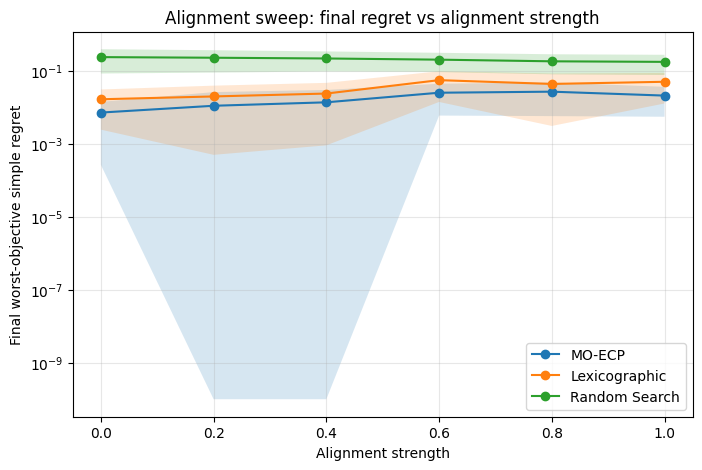

,alignment_strength,method,mean,std,count
0,0.0,Lexicographic,0.016317,0.013912,10
1,0.0,MO-ECP,0.007056,0.006796,10
2,0.0,Random Search,0.232755,0.149988,10
3,0.2,Lexicographic,0.019504,0.019012,10
4,0.2,MO-ECP,0.010828,0.014806,10
5,0.2,Random Search,0.223819,0.135975,10
6,0.4,Lexicographic,0.023400,0.022506,10
7,0.4,MO-ECP,0.013466,0.015893,10
8,0.4,Random Search,0.213560,0.119772,10
9,0.6,Lexicographic,0.054467,0.040689,10


In [44]:
alignment_levels = [1.0, 0.8, 0.6, 0.4, 0.2, 0.0]

sweep_df = alignment_sweep_experiment(
    base_f=base_f,
    x_star=x_star,
    params=params,
    alignment_levels=alignment_levels,
    misalign_scale=1.0,
    n=75,
    seeds=10,
    epsilon_init=1e-2,
    tau=1.1,
    max_rejects=20,
    ref_grid=201,
)

summary_df = plot_alignment_sweep(sweep_df)
summary_df

In [37]:
summary_table = (
    sweep_df.groupby(["alignment_strength", "method"])["final_regret"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["alignment_strength", "method"])
)

summary_table

,alignment_strength,method,mean,std
0,0.25,Lexicographic,0.012278,0.009466
1,0.25,MO-ECP,0.011758,0.009978
2,0.25,Random Search,0.072968,0.056706
3,0.40,Lexicographic,0.012128,0.009486
4,0.40,MO-ECP,0.011560,0.010208
5,0.40,Random Search,0.072320,0.056863
6,0.55,Lexicographic,0.011452,0.010011
7,0.55,MO-ECP,0.011165,0.010073
8,0.55,Random Search,0.071916,0.056866
9,0.70,Lexicographic,0.014505,0.010151


In comparing worst objective regret, our results show: $$\text{MO-ECP} ≈ \text{Lexicographic} << RandomSearch$$

which make sense since the numerical design was made so that objectives are almost scalarizable

# A more general class of lipschitz aligned objectives

In [47]:
import numpy as np

class CamelBase:
    """
    Tie-broken negated six-hump camel base benchmark with unique preferred maximizer.
    """
    def __init__(self, tie_weight=0.05):
        self.bounds = np.array([[-2, 2], [-1, 1]], dtype=float)
        self.x_star = np.array([0.0898, -0.7126], dtype=float)
        self.tie_weight = float(tie_weight)

    def camel_neg(self, x):
        x1, x2 = x
        return -(
            (4 - 2.1 * x1**2 + (x1**4) / 3.0) * x1**2
            + x1 * x2
            + (-4 + 4 * x2**2) * x2**2
        )

    def evaluate_scalar(self, x):
        x = np.asarray(x, dtype=float)
        # tie-breaks the two global maxima of the negated camel
        return self.camel_neg(x) - self.tie_weight * np.linalg.norm(x - self.x_star, ord=2)

class GenericAlignedCamelFamily:
    """
    Full aligned Lipschitz family over a camel base:
        f_i(x) = a_i * h(x) + b_i - psi_i(x)

    Requirements for each psi_i:
      - psi_i(x_star) = 0
      - psi_i(x) >= 0 for all x in the box
      - psi_i is Lipschitz

    This is the general class. Your old radial family is just one special case.
    """
    def __init__(self, base_f, specs):
        self.base_f = base_f
        self.bounds = np.asarray(base_f.bounds, dtype=float)
        self.x_star = np.asarray(base_f.x_star, dtype=float)
        self.specs = specs

    def evaluate(self, x):
        x = np.asarray(x, dtype=float)
        h = float(self.base_f.evaluate_scalar(x))

        vals = []
        for spec in self.specs:
            a = float(spec["a"])
            b = float(spec.get("b", 0.0))
            psi = spec["psi"]  # callable: psi(x, x_star) -> nonnegative float
            penalty = float(psi(x, self.x_star))
            vals.append(a * h + b - penalty)

        return np.array(vals, dtype=float)
def psi_radial(weight=1.0):
    return lambda x, x_star: weight * np.linalg.norm(x - x_star, ord=2)

def psi_anisotropic(B, weight=1.0):
    B = np.asarray(B, dtype=float)
    return lambda x, x_star: weight * np.linalg.norm(B @ (x - x_star), ord=2)

def psi_l1(weight=1.0):
    return lambda x, x_star: weight * np.linalg.norm(x - x_star, ord=1)

def psi_truncated(B=None, weight=1.0, radius=1.0):
    if B is None:
        B = np.eye(2)
    B = np.asarray(B, dtype=float)
    return lambda x, x_star: weight * min(np.linalg.norm(B @ (x - x_star), ord=2), radius)

def psi_bump_sum(centers, weights, widths):
    """
    Smooth-ish nonnegative penalty:
        psi(x) = sum_k w_k * |phi_k(x) - phi_k(x_star)|
    with Gaussian bumps phi_k. Nonnegative and zero at x_star by construction.
    """
    centers = [np.asarray(c, dtype=float) for c in centers]
    weights = np.asarray(weights, dtype=float)
    widths = np.asarray(widths, dtype=float)

    def phi(x, c, s):
        return np.exp(-np.linalg.norm(x - c)**2 / (2.0 * s**2))

    def psi(x, x_star):
        total = 0.0
        for c, w, s in zip(centers, weights, widths):
            total += w * abs(phi(x, c, s) - phi(x_star, c, s))
        return total

    return psi

def psi_max_of_norms(B_list, weights):
    """
    psi(x) = max_k w_k ||B_k (x - x_star)||_2
    Nonnegative, zero at x_star, Lipschitz.
    """
    B_list = [np.asarray(B, dtype=float) for B in B_list]
    weights = np.asarray(weights, dtype=float)

    def psi(x, x_star):
        vals = [w * np.linalg.norm(B @ (x - x_star), ord=2) for B, w in zip(B_list, weights)]
        return max(vals)

    return psi

In [48]:
base_f = CamelBase(tie_weight=0.05)

specs = [
    {
        "a": 1.00,
        "b": 0.00,
        "psi": psi_radial(weight=0.15),
    },
    {
        "a": 1.05,
        "b": 0.10,
        "psi": psi_anisotropic(B=np.diag([2.0, 0.5]), weight=0.20),
    },
    {
        "a": 0.95,
        "b": -0.10,
        "psi": psi_l1(weight=0.10),
    },
    {
        "a": 1.02,
        "b": 0.05,
        "psi": psi_bump_sum(
            centers=[[-1.0, -0.5], [0.8, 0.2], [1.2, -0.6]],
            weights=[0.08, 0.05, 0.07],
            widths=[0.5, 0.3, 0.4],
        ),
    },
    {
        "a": 0.98,
        "b": 0.02,
        "psi": psi_max_of_norms(
            B_list=[np.diag([1.0, 3.0]), np.diag([2.5, 0.7])],
            weights=[0.08, 0.06],
        ),
    },
]

f = GenericAlignedCamelFamily(base_f, specs)

In [49]:
def make_scalarized_function(f, weights=None):
    m = len(f.evaluate(np.mean(f.bounds, axis=1)))
    if weights is None:
        weights = np.ones(m) / m
    weights = np.asarray(weights, dtype=float)
    weights = weights / np.sum(weights)

    def g(x):
        vals = np.asarray(f.evaluate(x), dtype=float)
        return float(np.dot(weights, vals))

    return g, weights


def compare_four_methods_once(
    f,
    n=75,
    epsilon_init=1e-2,
    tau=1.1,
    max_rejects=20,
    seed=0,
    ref_grid=201,
):
    rng_mo = np.random.default_rng(seed)
    rng_scalar = np.random.default_rng(seed + 1)
    rng_lex = np.random.default_rng(seed + 2)
    rng_rand = np.random.default_rng(seed + 3)

    # Reference compromise point for misaligned / approximate-aligned families
    x_ref, ref_vals, ref_score = approximate_common_reference_2d(f, grid=ref_grid)

    # MO-ECP
    mo_points, mo_values_list, mo_eps = MO_ECP_seeded(
        f, n=n, epsilon_init=epsilon_init, tau=tau, max_rejects=max_rejects, rng=rng_mo
    )
    mo_regret, _, _ = evaluate_worst_regret_to_reference(mo_points, f, x_ref)

    # Scalarization
    scalar_g, scalar_weights = make_scalarized_function(f)
    scalar_points, scalar_values, scalar_eps = ECP_scalar(
        g=scalar_g, bounds=f.bounds, n=n, epsilon_init=epsilon_init, tau=tau, max_rejects=max_rejects, rng=rng_scalar
    )
    scalar_regret, _, _ = evaluate_worst_regret_to_reference(scalar_points, f, x_ref)

    # Lexicographic
    lex_g, lex_weights, lex_scales = make_lexicographic_scalarized_function(f)
    lex_points, lex_values, lex_eps = ECP_scalar(
        g=lex_g, bounds=f.bounds, n=n, epsilon_init=epsilon_init, tau=tau, max_rejects=max_rejects, rng=rng_lex
    )
    lex_regret, _, _ = evaluate_worst_regret_to_reference(lex_points, f, x_ref)

    # Random search
    rand_points = random_search(f.bounds, n=n, rng=rng_rand)
    rand_regret, _, _ = evaluate_worst_regret_to_reference(rand_points, f, x_ref)

    return {
        "x_ref": x_ref,
        "ref_vals": ref_vals,
        "ref_score_min": ref_score,
        "MO-ECP": {"regret": mo_regret, "final_regret": mo_regret[-1]},
        "Scalarization": {"regret": scalar_regret, "final_regret": scalar_regret[-1]},
        "Lexicographic": {"regret": lex_regret, "final_regret": lex_regret[-1]},
        "Random Search": {"regret": rand_regret, "final_regret": rand_regret[-1]},
    }


def richer_family_experiment(
    specs,
    n=75,
    seeds=10,
    epsilon_init=1e-2,
    tau=1.1,
    max_rejects=20,
    ref_grid=201,
):
    base_f = CamelBase(tie_weight=0.05)
    f_rich = GenericAlignedCamelFamily(base_f, specs)

    records = []
    curves = {k: [] for k in ["MO-ECP", "Scalarization", "Lexicographic", "Random Search"]}

    for seed in range(seeds):
        res = compare_four_methods_once(
            f_rich,
            n=n,
            epsilon_init=epsilon_init,
            tau=tau,
            max_rejects=max_rejects,
            seed=seed,
            ref_grid=ref_grid,
        )

        for method in curves:
            curves[method].append(res[method]["regret"])
            records.append({
                "seed": seed,
                "method": method,
                "final_regret": res[method]["final_regret"],
            })

    df = pd.DataFrame(records)
    curve_summary = {}
    for method in curves:
        arr = np.array(curves[method], dtype=float)  # (seeds, n)
        curve_summary[method] = {
            "mean": arr.mean(axis=0),
            "std": arr.std(axis=0),
            "median": np.median(arr, axis=0),
            "q25": np.quantile(arr, 0.25, axis=0),
            "q75": np.quantile(arr, 0.75, axis=0),
        }

    return f_rich, df, curve_summary


def plot_four_method_curves_iqr(curve_summary, title="Richer aligned Camel family"):
    plt.figure(figsize=(8, 5))
    for method in ["MO-ECP", "Scalarization", "Lexicographic", "Random Search"]:
        med = curve_summary[method]["median"]
        q25 = curve_summary[method]["q25"]
        q75 = curve_summary[method]["q75"]

        plt.plot(med, label=method)
        plt.fill_between(np.arange(len(med)), q25, q75, alpha=0.18)

    plt.yscale("log")
    plt.xlabel("Accepted samples / evaluations")
    plt.ylabel("Worst-objective simple regret")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def summarize_final_regret(df):
    summary = (
        df.groupby("method")["final_regret"]
        .agg(["mean", "std", "median"])
        .reset_index()
        .sort_values("mean")
    )
    return summary

## Algorithms compared

We compare four sampling strategies under a fixed evaluation budget $T$.

$\textbf{MO-ECP.}$
The multiobjective ECP algorithm maintains a separate Lipschitz envelope for each objective.
A candidate point $x$ is accepted if it is not dominated by the upper envelope of previously evaluated samples:
$$
\max_{j\in[m]} f_j(x_s) - \min_s \left(f_j(x_s) + \epsilon_j \|x-x_s\|\right) \le 0
\quad \forall j \in [m].
$$
Each objective maintains its own Lipschitz parameter $\epsilon_j$, which is adaptively increased after repeated rejections.

$\textbf{Scalarization + ECP.}$
The objectives are first combined using a weighted sum
$$
g(x) = \sum_{i=1}^m w_i f_i(x),
$$
with uniform weights $w_i = 1/m$.  
The standard scalar ECP algorithm is then applied to $g(x)$ using the same acceptance rule as the original ECP method.

$\textbf{Lexicographic ECP.}$
Objectives are combined using exponentially decaying weights
$$
g(x) = \sum_{i=1}^m \alpha^{m-i} f_i(x),
$$
with $\alpha=100$, approximating lexicographic priority.  
Scalar ECP is then applied to the resulting function.

$\textbf{Random Search.}$
Points are sampled uniformly from the domain without any acceptance filtering.

##Evaluation metric
Performance is measured using the worst-objective simple regret
$$
R_t^{\text{worst}}
= \max_i \left(
f_i(x^\star) - \max_{s \le t} f_i(x_s)
\right),
$$
where $x^\star$ is an approximate compromise optimum computed via dense grid search.
Results are averaged over 10 random seeds.

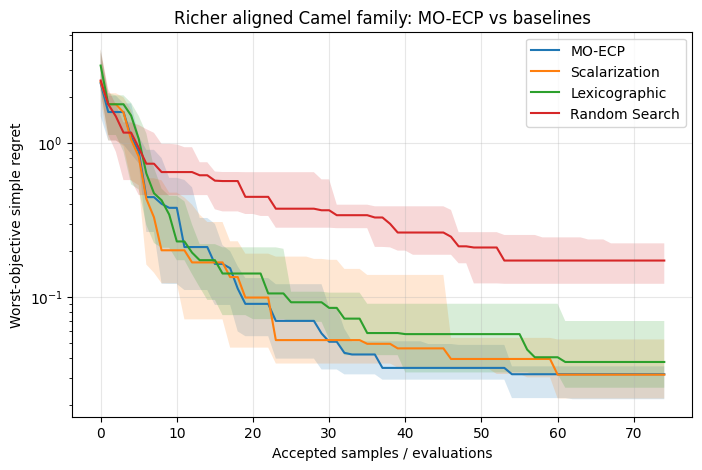

,method,mean,std,median
1,MO-ECP,0.029683,0.013862,0.031548
3,Scalarization,0.051799,0.049808,0.031346
0,Lexicographic,0.054910,0.044283,0.037883
2,Random Search,0.178097,0.098731,0.172581


In [50]:
# richer family from your new general class
base_f = CamelBase(tie_weight=0.05)

specs = [
    {"a": 1.00, "b": 0.00, "psi": psi_radial(weight=0.15)},
    {"a": 1.05, "b": 0.10, "psi": psi_anisotropic(B=np.diag([2.0, 0.5]), weight=0.20)},
    {"a": 0.95, "b": -0.10, "psi": psi_l1(weight=0.10)},
    {
        "a": 1.02,
        "b": 0.05,
        "psi": psi_bump_sum(
            centers=[[-1.0, -0.5], [0.8, 0.2], [1.2, -0.6]],
            weights=[0.08, 0.05, 0.07],
            widths=[0.5, 0.3, 0.4],
        ),
    },
    {
        "a": 0.98,
        "b": 0.02,
        "psi": psi_max_of_norms(
            B_list=[np.diag([1.0, 3.0]), np.diag([2.5, 0.7])],
            weights=[0.08, 0.06],
        ),
    },
]

f_rich, rich_df, rich_curves = richer_family_experiment(
    specs=specs,
    n=75,
    seeds=10,
    epsilon_init=1e-2,
    tau=1.1,
    max_rejects=20,
    ref_grid=201,
)

plot_four_method_curves_iqr(rich_curves, title="Richer aligned Camel family: MO-ECP vs baselines")
rich_summary = summarize_final_regret(rich_df)
rich_summary

In [51]:
x_ref, ref_vals, ref_score = approximate_common_reference_2d(f, grid=401)
print(x_ref)
print(base_f.x_star)

[ 0.09  -0.715]
[ 0.0898 -0.7126]


## family of lipschitz optimal camel functions, with near-optimal decoy regions

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class DeceptiveAlignedCamelFamily:
    """
    f_i(x) = a_i h(x) + b_i - psi_i(x, x_star) + bump_i(x) - bump_i(x_star)

    bump_i is centered at an objective-specific decoy center c_i.
    Its amplitude is calibrated so that the decoy is near-optimal but
    still strictly below x_star, preserving a shared global maximizer.
    """
    def __init__(self, base_f, specs):
        self.base_f = base_f
        self.bounds = np.asarray(base_f.bounds, dtype=float)
        self.x_star = np.asarray(base_f.x_star, dtype=float)
        self.specs = specs

        # Calibrate bump amplitudes so x_star stays the maximizer
        h_star = float(self.base_f.evaluate_scalar(self.x_star))
        self._amps = []
        for spec in self.specs:
            a = float(spec["a"])
            b = float(spec.get("b", 0.0))
            psi = spec["psi"]
            c = np.asarray(spec["decoy_center"], dtype=float)
            frac = float(spec.get("decoy_frac", 0.90))

            base_star = a * h_star + b - float(psi(self.x_star, self.x_star))
            base_center = a * float(self.base_f.evaluate_scalar(c)) + b - float(psi(c, self.x_star))

            gap = max(base_star - base_center, 1e-4)
            amp = frac * gap
            self._amps.append(amp)

    def _gaussian(self, x, center, sigma, amp):
        x = np.asarray(x, dtype=float)
        center = np.asarray(center, dtype=float)
        return amp * np.exp(-np.linalg.norm(x - center)**2 / (2.0 * sigma**2))

    def evaluate(self, x):
        x = np.asarray(x, dtype=float)
        h = float(self.base_f.evaluate_scalar(x))

        vals = []
        for spec, amp in zip(self.specs, self._amps):
            a = float(spec["a"])
            b = float(spec.get("b", 0.0))
            psi = spec["psi"]
            center = np.asarray(spec["decoy_center"], dtype=float)
            sigma = float(spec.get("sigma", 0.16))

            penalty = float(psi(x, self.x_star))
            bump_x = self._gaussian(x, center, sigma, amp)
            bump_star = self._gaussian(self.x_star, center, sigma, amp)

            vals.append(a * h + b - penalty + bump_x - bump_star)

        return np.array(vals, dtype=float)


base_f = CamelBase(tie_weight=0.05)

specs_deceptive = [
    {
        "a": 1.00,
        "b": 0.00,
        "psi": psi_anisotropic(B=np.diag([2.5, 0.7]), weight=0.22),
        "decoy_center": [-1.10, -0.20],
        "sigma": 0.14,
        "decoy_frac": 0.93,
    },
    {
        "a": 1.05,
        "b": 0.05,
        "psi": psi_anisotropic(B=np.diag([0.8, 2.8]), weight=0.24),
        "decoy_center": [1.15, 0.35],
        "sigma": 0.16,
        "decoy_frac": 0.92,
    },
    {
        "a": 0.95,
        "b": -0.08,
        "psi": psi_l1(weight=0.16),
        "decoy_center": [-0.95, 0.65],
        "sigma": 0.15,
        "decoy_frac": 0.94,
    },
    {
        "a": 1.02,
        "b": 0.04,
        "psi": psi_max_of_norms(
            B_list=[np.diag([1.0, 3.5]), np.diag([3.0, 0.8])],
            weights=[0.10, 0.08],
        ),
        "decoy_center": [0.95, -0.85],
        "sigma": 0.14,
        "decoy_frac": 0.93,
    },
    {
        "a": 0.98,
        "b": 0.02,
        "psi": psi_bump_sum(
            centers=[[-1.2, -0.6], [0.7, 0.25], [1.25, -0.45]],
            weights=[0.10, 0.07, 0.08],
            widths=[0.45, 0.28, 0.35],
        ),
        "decoy_center": [0.25, 0.75],
        "sigma": 0.13,
        "decoy_frac": 0.92,
    },
]

f_deceptive = DeceptiveAlignedCamelFamily(base_f, specs_deceptive)

##Deceptive aligned Camel family
To produce a more diagnostic stress test, we augment the aligned Camel family with objective-specific near-optimal decoy bumps. Concretely, each objective takes the form
$$
f_i(x)
=
a_i h(x) + b_i - \psi_i(x,x^\star) + \beta_i(x) - \beta_i(x^\star),
$$
where $h$ is the tie-broken negated six-hump Camel benchmark, $\psi_i$ is a Lipschitz penalty preserving alignment at the common optimizer $x^\star$, and $\beta_i$ is a Gaussian bump centered at an objective-specific decoy location. The bump amplitudes are calibrated so that each decoy remains near-optimal but strictly suboptimal relative to $x^\star$. This construction creates strong local distractors for scalarization and lexicographic baselines while preserving a shared global optimum, thereby providing a clearer setting in which multi-objective acceptance can outperform single-scalar reductions.

In [64]:
def calibrate_decoy_amplitude(base_f, a, b, psi, center, sigma, x_star, bounds, eps_tol=1e-3, grid=201, max_amp=5.0):
    """
    Find the largest amplitude A such that
        max_x f_A(x) - f_A(x_star) <= eps_tol
    on a dense grid,
    where
        f_A(x) = a h(x) + b - psi(x, x_star) + A*g(x) - A*g(x_star),
    and g is a Gaussian bump centered at 'center'.

    This gives a numerically controlled near-aligned decoy.
    """
    bounds = np.asarray(bounds, dtype=float)
    x_star = np.asarray(x_star, dtype=float)
    center = np.asarray(center, dtype=float)

    xs = np.linspace(bounds[0, 0], bounds[0, 1], grid)
    ys = np.linspace(bounds[1, 0], bounds[1, 1], grid)

    def gaussian(x):
        return np.exp(-np.linalg.norm(x - center)**2 / (2.0 * sigma**2))

    def gap_for_amp(A):
        vals = []
        for x1 in xs:
            for x2 in ys:
                x = np.array([x1, x2], dtype=float)
                h = float(base_f.evaluate_scalar(x))
                val = a * h + b - float(psi(x, x_star)) + A * gaussian(x) - A * gaussian(x_star)
                vals.append(val)
        vals = np.array(vals)

        h_star = float(base_f.evaluate_scalar(x_star))
        val_star = a * h_star + b - float(psi(x_star, x_star)) + A * gaussian(x_star) - A * gaussian(x_star)
        return np.max(vals) - val_star

    lo, hi = 0.0, max_amp
    while gap_for_amp(hi) <= eps_tol:
        hi *= 2.0
        if hi > 1e3:
            break

    for _ in range(30):
        mid = 0.5 * (lo + hi)
        if gap_for_amp(mid) <= eps_tol:
            lo = mid
        else:
            hi = mid

    return lo
class CalibratedDeceptiveAlignedCamelFamily:
    def __init__(self, base_f, specs, eps_tol=1e-3, calib_grid=201):
        self.base_f = base_f
        self.bounds = np.asarray(base_f.bounds, dtype=float)
        self.x_star = np.asarray(base_f.x_star, dtype=float)
        self.specs = specs
        self._amps = []

        for spec in specs:
            a = float(spec["a"])
            b = float(spec.get("b", 0.0))
            psi = spec["psi"]
            center = np.asarray(spec["decoy_center"], dtype=float)
            sigma = float(spec.get("sigma", 0.12))
            frac = float(spec.get("decoy_frac", 0.95))

            # compute maximal safe amplitude
            A_safe = calibrate_decoy_amplitude(
                base_f=base_f,
                a=a,
                b=b,
                psi=psi,
                center=center,
                sigma=sigma,
                x_star=self.x_star,
                bounds=self.bounds,
                eps_tol=eps_tol,
                grid=calib_grid,
                max_amp=5.0,
            )

            # user still controls relative strength, but now within a safe range
            self._amps.append(frac * A_safe)

    def _gaussian(self, x, center, sigma, amp):
        x = np.asarray(x, dtype=float)
        center = np.asarray(center, dtype=float)
        return amp * np.exp(-np.linalg.norm(x - center)**2 / (2.0 * sigma**2))

    def evaluate(self, x):
        x = np.asarray(x, dtype=float)
        h = float(self.base_f.evaluate_scalar(x))
        vals = []

        for spec, amp in zip(self.specs, self._amps):
            a = float(spec["a"])
            b = float(spec.get("b", 0.0))
            psi = spec["psi"]
            center = np.asarray(spec["decoy_center"], dtype=float)
            sigma = float(spec.get("sigma", 0.12))

            penalty = float(psi(x, self.x_star))
            bump_x = self._gaussian(x, center, sigma, amp)
            bump_star = self._gaussian(self.x_star, center, sigma, amp)

            vals.append(a * h + b - penalty + bump_x - bump_star)

        return np.array(vals, dtype=float)

In [65]:
rich_summary = summarize_final_regret(rich_df)
rich_summary

,method,mean,std,median
1,MO-ECP,0.029683,0.013862,0.031548
3,Scalarization,0.051799,0.049808,0.031346
0,Lexicographic,0.054910,0.044283,0.037883
2,Random Search,0.178097,0.098731,0.172581


In [59]:
x_ref, ref_vals, ref_score = approximate_common_reference_2d(f_deceptive, grid=401)
print("reference compromise point:", x_ref)
print("base x_star:", base_f.x_star)
print("reference values:", ref_vals)
print("reference min-objective value:", ref_score)

reference compromise point: [ 0.09  -0.715]
base x_star: [ 0.0898 -0.7126]
reference values: [1.03107756 1.13142309 0.89947403 1.09125221 1.03082845]
reference min-objective value: 0.8994740261368515


In [60]:
def approximate_per_objective_maxima_2d(f, grid=301):
    bounds = np.asarray(f.bounds, dtype=float)
    xs = np.linspace(bounds[0, 0], bounds[0, 1], grid)
    ys = np.linspace(bounds[1, 0], bounds[1, 1], grid)

    m = len(f.evaluate(np.array([xs[0], ys[0]], dtype=float)))
    best_x = [None] * m
    best_v = [-np.inf] * m

    for x1 in xs:
        for x2 in ys:
            x = np.array([x1, x2], dtype=float)
            vals = f.evaluate(x)
            for i in range(m):
                if vals[i] > best_v[i]:
                    best_v[i] = vals[i]
                    best_x[i] = x.copy()

    return best_x, best_v

best_xs, best_vs = approximate_per_objective_maxima_2d(f_deceptive, grid=301)
for i, (bx, bv) in enumerate(zip(best_xs, best_vs), start=1):
    print(f"obj {i}: x_max ≈ {bx}, f_max ≈ {bv:.6f}")

obj 1: x_max ≈ [ 0.09333333 -0.71333333], f_max ≈ 1.029453
obj 2: x_max ≈ [ 0.09333333 -0.71333333], f_max ≈ 1.132131
obj 3: x_max ≈ [ 0.09333333 -0.71333333], f_max ≈ 0.899147
obj 4: x_max ≈ [ 0.09333333 -0.71333333], f_max ≈ 1.091178
obj 5: x_max ≈ [0.16       0.72666667], f_max ≈ 1.097182


## Demonstration setting where MO-ECP has a clear advantage

To more clearly expose the advantage of MO-ECP, we construct a deceptive near-aligned Camel family in which each objective shares the same preferred optimizer $x^\star$ up to a small tolerance, but also contains an objective-specific near-optimal decoy region. Concretely, each objective is of the form
$$
f_i(x)=a_i h(x)+b_i-\psi_i(x,x^\star)+\beta_i(x)-\beta_i(x^\star),
$$
where $h$ is the tie-broken negated six-hump Camel function, $\psi_i$ is a nonnegative Lipschitz penalty satisfying $\psi_i(x^\star)=0$, and $\beta_i$ is a Gaussian bump centered at an objective-specific decoy. The bump amplitudes are calibrated so that the decoys remain highly competitive but typically suboptimal relative to $x^\star$. This setting is intentionally designed to stress scalar reductions, which may be attracted to objective-specific traps, whereas MO-ECP retains an advantage by enforcing simultaneous admissibility across objectives.

##MO-ECP's advantage is structure-dependent
MO-ECP is not expected to dominate uniformly across all objective families. In nearly scalarizable aligned settings, scalarization and lexicographic reductions can perform similarly, since all objectives share essentially the same global geometry. The advantage of MO-ECP emerges more clearly when objectives remain globally near-aligned but contain distinct local decoy regions that are attractive to scalar reductions. In such cases, enforcing simultaneous admissibility across objectives provides a stronger inductive bias than optimizing any single scalar reduction.

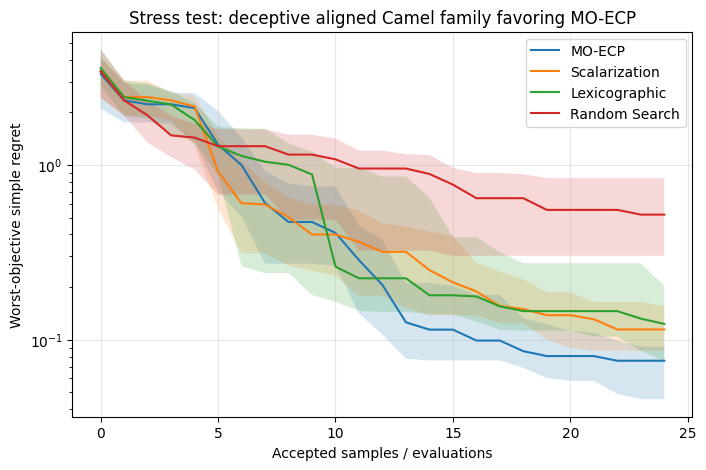

,method,mean,std,median
1,MO-ECP,0.075211,0.043380,0.075658
3,Scalarization,0.140096,0.096269,0.114305
0,Lexicographic,0.166284,0.131752,0.122974
2,Random Search,0.590959,0.416217,0.519855


In [61]:
## Stronger stress test: deceptive aligned family favoring MO-ECP

base_f = CamelBase(tie_weight=0.05)

specs_demo = [
    {
        "a": 1.00,
        "b": 0.00,
        "psi": psi_anisotropic(B=np.diag([3.0, 0.8]), weight=0.28),
        "decoy_center": [-1.15, -0.15],
        "sigma": 0.10,
        "decoy_frac": 0.985,
    },
    {
        "a": 1.04,
        "b": 0.04,
        "psi": psi_anisotropic(B=np.diag([0.7, 3.2]), weight=0.30),
        "decoy_center": [1.20, 0.30],
        "sigma": 0.10,
        "decoy_frac": 0.985,
    },
    {
        "a": 0.96,
        "b": -0.06,
        "psi": psi_l1(weight=0.20),
        "decoy_center": [-0.95, 0.72],
        "sigma": 0.09,
        "decoy_frac": 0.99,
    },
    {
        "a": 1.02,
        "b": 0.03,
        "psi": psi_max_of_norms(
            B_list=[np.diag([1.0, 4.0]), np.diag([3.2, 0.7])],
            weights=[0.12, 0.10],
        ),
        "decoy_center": [0.95, -0.88],
        "sigma": 0.09,
        "decoy_frac": 0.985,
    },
    {
        "a": 0.99,
        "b": 0.01,
        "psi": psi_bump_sum(
            centers=[[-1.25, -0.55], [0.75, 0.20], [1.20, -0.50]],
            weights=[0.12, 0.08, 0.10],
            widths=[0.35, 0.22, 0.28],
        ),
        "decoy_center": [0.30, 0.78],
        "sigma": 0.08,
        "decoy_frac": 0.99,
    },
]

f_demo = DeceptiveAlignedCamelFamily(base_f, specs_demo)

f_demo_obj, demo_df, demo_curves = richer_family_experiment(
    specs=specs_demo,
    n=25,
    seeds=20,
    epsilon_init=1e-2,
    tau=1.1,
    max_rejects=20,
    ref_grid=251,
)

plot_four_method_curves_iqr(
    demo_curves,
    title="Stress test: deceptive aligned Camel family favoring MO-ECP"
)

demo_summary = summarize_final_regret(demo_df)
demo_summary

In [62]:
def epsilon_alignment_report(f, x_star=None, grid=301):
    if x_star is None:
        x_star = f.x_star

    bounds = np.asarray(f.bounds, dtype=float)
    xs = np.linspace(bounds[0, 0], bounds[0, 1], grid)
    ys = np.linspace(bounds[1, 0], bounds[1, 1], grid)

    vals_star = np.asarray(f.evaluate(np.asarray(x_star, dtype=float)), dtype=float)
    m = len(vals_star)
    max_vals = np.full(m, -np.inf)

    for x1 in xs:
        for x2 in ys:
            x = np.array([x1, x2], dtype=float)
            vals = f.evaluate(x)
            max_vals = np.maximum(max_vals, vals)

    eps = max_vals - vals_star
    for i, e in enumerate(eps, start=1):
        print(f"obj {i}: epsilon_i ≈ {e:.6f}")

    return eps, vals_star, max_vals

eps_demo, vals_star_demo, max_vals_demo = epsilon_alignment_report(f_demo, x_star=base_f.x_star, grid=301)

obj 1: epsilon_i ≈ -0.003202
obj 2: epsilon_i ≈ -0.001261
obj 3: epsilon_i ≈ -0.001073
obj 4: epsilon_i ≈ -0.001366
obj 5: epsilon_i ≈ 0.039021


In [66]:
rich_summary = summarize_final_regret(rich_df)
rich_summary

,method,mean,std,median
1,MO-ECP,0.029683,0.013862,0.031548
3,Scalarization,0.051799,0.049808,0.031346
0,Lexicographic,0.054910,0.044283,0.037883
2,Random Search,0.178097,0.098731,0.172581
